In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные
df = pd.read_excel('hospital_patient_treatment.xlsx')
print("Данные загружены! Размер датасета:", df.shape)

Данные загружены! Размер датасета: (10000, 40)


In [9]:
#1
#1. Выбираем числовые колонки и создаём массив NumPy
numeric_cols = ['Age', 'Treatment_Cost', 'Days_in_Hospital',
                'Lab_Test_Count', 'Medication_Count',
                'Physical_Therapy_Sessions', 'ICU_Stay']
numeric_data = df[numeric_cols].to_numpy()
#2. Выводим форму массива
print(f'Форма массива: {numeric_data.shape}')
print('-' * 40)
#3. Выводим первые 5 строк
print('--- Первые 5 строк массива ---')
print(numeric_data[:5])

Форма массива: (10000, 7)
----------------------------------------
--- Первые 5 строк массива ---
[[5.100000e+01 2.393359e+04 2.700000e+01 1.700000e+01 0.000000e+00
  1.100000e+01 0.000000e+00]
 [9.200000e+01 3.071590e+03 1.000000e+00 1.800000e+01 9.000000e+00
  1.000000e+01 0.000000e+00]
 [1.400000e+01 2.414487e+04 1.200000e+01 1.000000e+01 0.000000e+00
  2.000000e+00 0.000000e+00]
 [7.100000e+01 3.231440e+03 5.000000e+00 4.000000e+00 3.000000e+00
  1.400000e+01 0.000000e+00]
 [6.000000e+01 1.736701e+04 1.700000e+01 1.200000e+01 6.000000e+00
  7.000000e+00 1.000000e+00]]


In [10]:
#2
#1. Считаем среднее, медиану и стандартное отклонение для Age
print(f'Age       | среднее: {np.mean(df["Age"]):.2f} | медиана: {np.median(df["Age"]):.2f} | std: {np.std(df["Age"]):.2f}')
#2. Для Treatment_Cost
print(f'Cost      | среднее: {np.mean(df["Treatment_Cost"]):.2f} | медиана: {np.median(df["Treatment_Cost"]):.2f} | std: {np.std(df["Treatment_Cost"]):.2f}')
#3. Для Days_in_Hospital
print(f'Days      | среднее: {np.mean(df["Days_in_Hospital"]):.2f} | медиана: {np.median(df["Days_in_Hospital"]):.2f} | std: {np.std(df["Days_in_Hospital"]):.2f}')

Age       | среднее: 49.29 | медиана: 49.00 | std: 28.87
Cost      | среднее: 25115.96 | медиана: 25228.56 | std: 14280.82
Days      | среднее: 14.89 | медиана: 15.00 | std: 8.33


In [11]:
#3
#1. Создаём массивы и считаём сумму процедур
cost_arr = df['Treatment_Cost'].to_numpy()
procedures = df['Lab_Test_Count'].to_numpy() + df['Medication_Count'].to_numpy()
#2. Фильтруем: Treatment_Cost > 20000 и процедур > 15
mask = (cost_arr > 20000) & (procedures > 15)
filtered_indices = np.where(mask)[0]
#3. Выводим первые 10 пациентов
print(f'Пациентов подходящих под критерии: {len(filtered_indices)}')
print('-' * 50)
print(f"{'Patient_ID':<15} {'Treatment_Cost':>16} {'Lab+Med':>10}")
print('-' * 50)
for idx in filtered_indices[:10]:
    print(f"{df['Patient_ID'].iloc[idx]:<15} {cost_arr[idx]:>16.2f} {procedures[idx]:>10.0f}")

Пациентов подходящих под критерии: 2626
--------------------------------------------------
Patient_ID        Treatment_Cost    Lab+Med
--------------------------------------------------
PAT_00001               23933.59         17
PAT_00011               26434.05         20
PAT_00016               23535.00         16
PAT_00019               34399.85         19
PAT_00021               31252.77         17
PAT_00023               45926.33         18
PAT_00025               42039.45         27
PAT_00028               35211.17         23
PAT_00031               24022.06         19
PAT_00032               31362.33         18


In [12]:
#4
#1. Создаём словарь: ключ = Department, значение = кол-во пациентов
department_counts = {}
for dept in df['Department']:
    department_counts[dept] = department_counts.get(dept, 0) + 1
#2. Выводим топ-2 отделения
top2 = sorted(department_counts.items(), key=lambda x: x[1], reverse=True)[:2]
print('--- Все отделения ---')
for dept, count in sorted(department_counts.items(), key=lambda x: x[1], reverse=True):
    print(f'  {dept:<20}: {count}')
print()
print('--- Топ-2 отделения ---')
for i, (dept, count) in enumerate(top2, 1):
    print(f'  {i}. {dept}: {count} пациентов')

--- Все отделения ---
  Oncology            : 1692
  Cardiology          : 1678
  Pediatrics          : 1667
  General Medicine    : 1664
  Orthopedics         : 1652
  Neurology           : 1647

--- Топ-2 отделения ---
  1. Oncology: 1692 пациентов
  2. Cardiology: 1678 пациентов


In [13]:
#5
#1. Создаём set уникальных Treatment_Type
treatment_types_set = set(df['Treatment_Type'])
#2. Создаём set уникальных Diagnosis
diagnosis_set = set(df['Diagnosis'])
#Вывод результатов
print(f'Уникальных типов лечения: {len(treatment_types_set)}')
print(treatment_types_set)
print()
print(f'Уникальных диагнозов: {len(diagnosis_set)}')
print(diagnosis_set)

Уникальных типов лечения: 4
{'Observation', 'Surgery', 'Medication', 'Therapy'}

Уникальных диагнозов: 7
{'Fracture', 'COVID-19', 'Hypertension', 'Cardiac Arrest', 'Diabetes', 'Migraine', 'Flu'}


In [14]:
#6
#1. Добавляем колонку Cost_per_Procedure через lambda
df['Cost_per_Procedure'] = df.apply(
    lambda row: row['Treatment_Cost'] / (row['Lab_Test_Count'] + row['Medication_Count'] + row['Physical_Therapy_Sessions'] + 1),
    axis=1
)
#2. Создаём генератор для пациентов с Treatment_Cost >= 25000
high_cost_patients = (row for row in df[df['Treatment_Cost'] >= 25000].itertuples())
#3. Выводим первые 10 пациентов генератора
print(f"{'Patient_ID':<15} | {'Treatment_Cost':>14} | {'Cost_per_Procedure':>18}")
print('-' * 55)
count = 0
for patient in high_cost_patients:
    if count >= 10:
        break
    print(f"{patient.Patient_ID:<15} | {patient.Treatment_Cost:>14.2f} | {patient.Cost_per_Procedure:>18.2f}")
    count += 1

Patient_ID      | Treatment_Cost | Cost_per_Procedure
-------------------------------------------------------
PAT_00011       |       26434.05 |             911.52
PAT_00013       |       42009.27 |            2211.01
PAT_00014       |       41313.66 |            2430.22
PAT_00015       |       41231.46 |            2576.97
PAT_00019       |       34399.85 |            1146.66
PAT_00020       |       26536.34 |            2211.36
PAT_00021       |       31252.77 |            1736.27
PAT_00022       |       34716.52 |            4339.56
PAT_00023       |       45926.33 |            1583.67
PAT_00024       |       47204.39 |            2247.83


In [15]:
#7
#1. Создаём сводную таблицу: index=Department, columns=Treatment_Type, values=средний Treatment_Cost
pivot_table = pd.pivot_table(df, index='Department', columns='Treatment_Type',
                             values='Treatment_Cost', aggfunc='mean')
#2. Выводим таблицу
print('--- Средняя стоимость лечения по отделениям и типам процедур ---')
print(pivot_table.round(2))
#3. Находим максимум
max_dept = pivot_table.stack().idxmax()[0]
max_type = pivot_table.stack().idxmax()[1]
print(f'\nСамая высокая стоимость: {max_dept} / {max_type} — ${pivot_table.stack().max():.2f}')

--- Средняя стоимость лечения по отделениям и типам процедур ---
Treatment_Type    Medication  Observation   Surgery   Therapy
Department                                                   
Cardiology          25291.18     24308.05  25576.93  25076.89
General Medicine    25162.14     24769.91  24357.14  24662.86
Neurology           24830.69     25176.40  23764.41  25397.51
Oncology            25093.38     24284.32  25886.38  24847.81
Orthopedics         26485.98     24943.40  25335.96  26194.55
Pediatrics          26165.32     25770.93  24579.64  24902.88

Самая высокая стоимость: Orthopedics / Medication — $26485.98


In [16]:
#8
#1. Сохраняем DataFrame с Cost_per_Procedure в CSV
df.to_csv('student2_cost_ratio.csv', index=False)
print('student2_cost_ratio.csv сохранён')
#2. Сохраняем сводную таблицу в Excel
pivot_table.to_excel('student2_department_treatment.xlsx')
print('student2_department_treatment.xlsx сохранён')
#3. Читаем CSV обратно и проверяем
df_check = pd.read_csv('student2_cost_ratio.csv')
match = np.allclose(df['Cost_per_Procedure'].values, df_check['Cost_per_Procedure'].values, rtol=1e-5)
print(f'Данные совпадают: {"✓ ДА" if match else "✗ НЕТ"}')
print(f'Строк исходно: {len(df)}, строк в CSV: {len(df_check)}')

student2_cost_ratio.csv сохранён
student2_department_treatment.xlsx сохранён
Данные совпадают: ✓ ДА
Строк исходно: 10000, строк в CSV: 10000


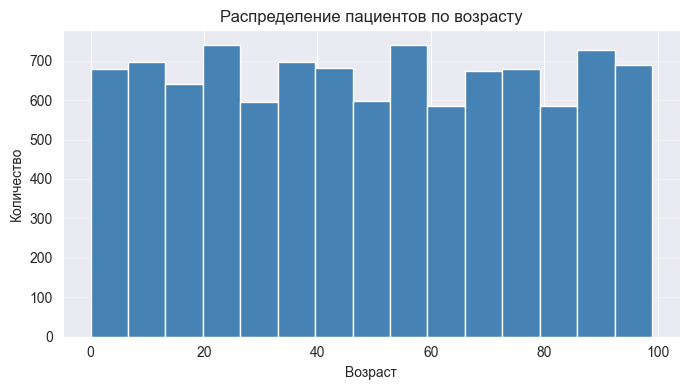

In [20]:
#9
#1. Гистограмма Age с 15 бинами
plt.figure(figsize=(7, 4))
plt.hist(df['Age'], bins=15, color='steelblue', edgecolor='white')
plt.title('Распределение пациентов по возрасту')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('student2_age_hist.png', dpi=150)
plt.show()

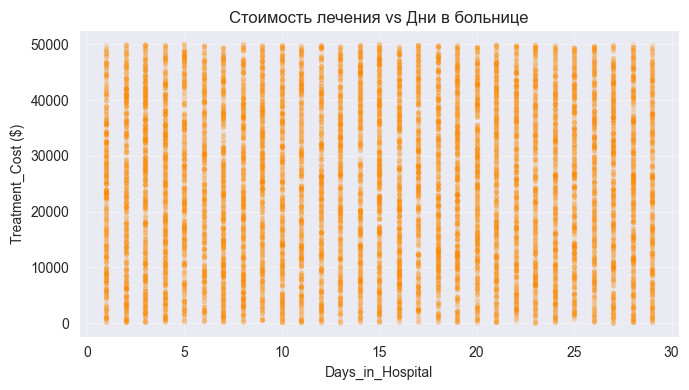

Графики сохранены: student2_age_hist.png, student2_scatter.png


In [19]:
#9
#2. Scatter plot: Treatment_Cost vs Days_in_Hospital
plt.figure(figsize=(7, 4))
plt.scatter(df['Days_in_Hospital'], df['Treatment_Cost'], alpha=0.15, s=8, color='darkorange')
plt.title('Стоимость лечения vs Дни в больнице')
plt.xlabel('Days_in_Hospital')
plt.ylabel('Treatment_Cost ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('student2_scatter.png', dpi=150)
plt.show()
print('Графики сохранены: student2_age_hist.png, student2_scatter.png')

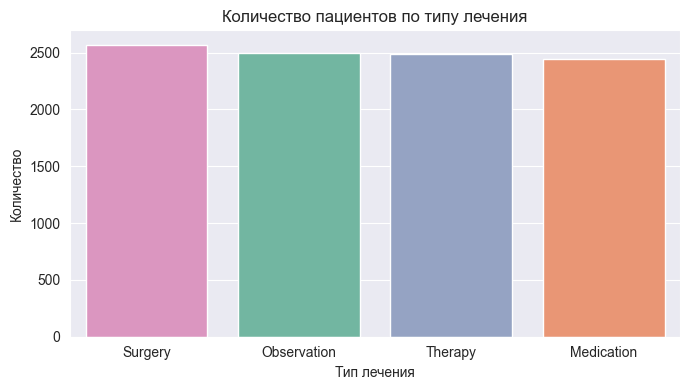

In [25]:
#10
#1. Countplot по Treatment_Type
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Treatment_Type', hue='Treatment_Type', palette='Set2',
              order=df['Treatment_Type'].value_counts().index, legend=False)
plt.title('Количество пациентов по типу лечения')
plt.xlabel('Тип лечения')
plt.ylabel('Количество')
plt.tight_layout()
plt.savefig('student2_countplot.png', dpi=150)
plt.show()

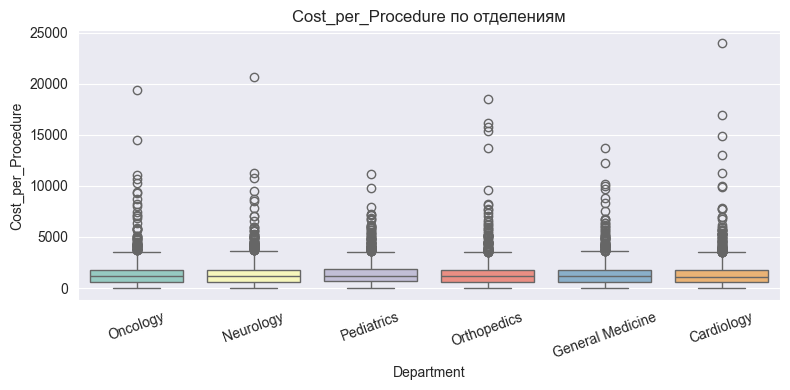

In [28]:
#10
#2. Boxplot Cost_per_Procedure по Department
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Department', y='Cost_per_Procedure', hue='Department', palette='Set3', legend=False)
plt.title('Cost_per_Procedure по отделениям')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('student2_boxplot.png', dpi=150)
plt.show()

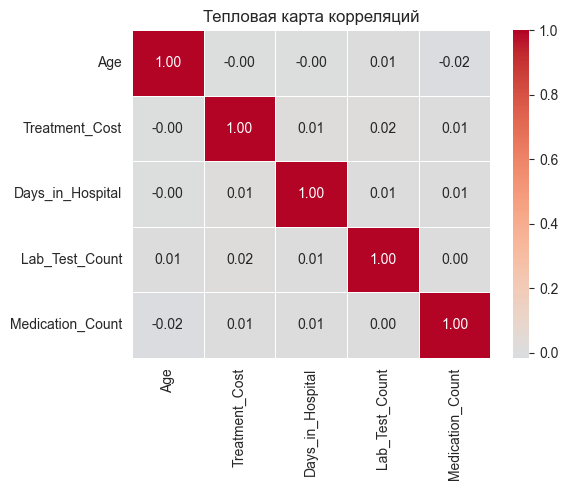

Графики сохранены: student2_countplot.png, student2_boxplot.png, student2_heatmap.png


In [24]:
#10
#3. Heatmap корреляции
corr_cols = ['Age', 'Treatment_Cost', 'Days_in_Hospital', 'Lab_Test_Count', 'Medication_Count']
plt.figure(figsize=(6, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.savefig('student2_heatmap.png', dpi=150)
plt.show()
print('Графики сохранены: student2_countplot.png, student2_boxplot.png, student2_heatmap.png')